In [2]:
import numpy as np
import time
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train).reshape(-1, 1)
y_test = torch.FloatTensor(y_test).reshape(-1, 1)

Perceptron (2–1)

In [3]:
class Perceptron(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 1)
    
    def forward(self, x):
        return torch.sigmoid(self.linear(x))


model = Perceptron()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

start_time = time.time()

for epoch in range(500):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

training_time = time.time() - start_time

with torch.no_grad():
    preds = model(X_test)
    preds = (preds > 0.5).float()

accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)
f1 = f1_score(y_test, preds)

print("Perceptron Results:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("Training time:", training_time)

Perceptron Results:
Accuracy: 0.855
Precision: 0.8514851485148515
Recall: 0.86
F1: 0.8557213930348259
Training time: 0.24974679946899414


MLP (2–4–1)

In [4]:
class MLP_4(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)


model = MLP_4()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

start_time = time.time()

for epoch in range(500):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

training_time = time.time() - start_time

with torch.no_grad():
    preds = model(X_test)
    preds = (preds > 0.5).float()

accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)
f1 = f1_score(y_test, preds)

print("MLP (2-4-1) Results:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("Training time:", training_time)

MLP (2-4-1) Results:
Accuracy: 0.88
Precision: 0.8584905660377359
Recall: 0.91
F1: 0.883495145631068
Training time: 0.3698699474334717


In [5]:
class MLP_4(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)


model = MLP_4()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

start_time = time.time()

for epoch in range(500):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

training_time = time.time() - start_time

with torch.no_grad():
    preds = model(X_test)
    preds = (preds > 0.5).float()

accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)
f1 = f1_score(y_test, preds)

print("MLP (2-8-1) Results:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("Training time:", training_time)

MLP (2-8-1) Results:
Accuracy: 0.98
Precision: 0.98
Recall: 0.98
F1: 0.98
Training time: 0.35892319679260254


In [6]:
class MLP_4(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)


model = MLP_4()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

start_time = time.time()

for epoch in range(500):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

training_time = time.time() - start_time

with torch.no_grad():
    preds = model(X_test)
    preds = (preds > 0.5).float()

accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)
f1 = f1_score(y_test, preds)

print("MLP (2-8-8-1) Results:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("Training time:", training_time)

MLP (2-8-8-1) Results:
Accuracy: 0.985
Precision: 1.0
Recall: 0.97
F1: 0.9847715736040609
Training time: 0.4634060859680176


In [7]:
class MLP_4(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)


model = MLP_4()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

start_time = time.time()

for epoch in range(500):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

training_time = time.time() - start_time

with torch.no_grad():
    preds = model(X_test)
    preds = (preds > 0.5).float()

accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)
f1 = f1_score(y_test, preds)

print("MLP (2-16-8-1) Results:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("Training time:", training_time)

MLP (2-16-8-1) Results:
Accuracy: 0.99
Precision: 1.0
Recall: 0.98
F1: 0.98989898989899
Training time: 0.5013833045959473


In [9]:
class MLP_4(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)


model = MLP_4()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

start_time = time.time()

for epoch in range(500):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

training_time = time.time() - start_time

with torch.no_grad():
    preds = model(X_test)
    preds = (preds > 0.5).float()

accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)
f1 = f1_score(y_test, preds)

print("MLP (2-32-1) Results:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("Training time:", training_time)

MLP (2-32-1) Results:
Accuracy: 0.975
Precision: 0.9896907216494846
Recall: 0.96
F1: 0.9746192893401016
Training time: 0.36064863204956055


In [8]:
class MLP_4(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)


model = MLP_4()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

start_time = time.time()

for epoch in range(500):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

training_time = time.time() - start_time

with torch.no_grad():
    preds = model(X_test)
    preds = (preds > 0.5).float()

accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)
f1 = f1_score(y_test, preds)

print("MLP (2-16-16-1) Results:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("Training time:", training_time)

MLP (2-16-16-1) Results:
Accuracy: 0.99
Precision: 1.0
Recall: 0.98
F1: 0.98989898989899
Training time: 0.43576908111572266


In [6]:
import pandas as pd

hidden_neurons_list = [4, 8, 16, 32, 64]
results = []

for N in hidden_neurons_list:
    class MLPWidth(nn.Module):
        def __init__(self):
            super().__init__()
            self.model = nn.Sequential(
                nn.Linear(2, N),
                nn.ReLU(),
                nn.Linear(N, 1),
                nn.Sigmoid()
            )
        def forward(self, x):
            return self.model(x)

    model = MLPWidth()
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    start_time = time.time()
    for epoch in range(500):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
    training_time = time.time() - start_time

    with torch.no_grad():
        preds = model(X_test)
        preds = (preds > 0.5).float()

    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    parameters = (2 * N + N) + (N * 1 + 1)  

    results.append({
        "Hidden Neurons": N,
        "Parameters": parameters,
        "Accuracy": round(accuracy, 3),
        "F1-Score": round(f1, 3),
        "Training Time (s)": round(training_time, 3)
    })

df = pd.DataFrame(results)
print(df)

   Hidden Neurons  Parameters  Accuracy  F1-Score  Training Time (s)
0               4          17     0.970     0.970              0.364
1               8          33     0.975     0.975              0.344
2              16          65     0.980     0.980              0.337
3              32         129     0.990     0.990              0.332
4              64         257     0.990     0.990              0.385


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

hidden_layers_list = [
    [8],
    [8, 8],
    [8, 8, 8],
    [8, 8, 8, 8]
]

results = []

for layers in hidden_layers_list:
    modules = []
    input_size = 2
    for h in layers:
        modules.append(nn.Linear(input_size, h))
        modules.append(nn.ReLU())
        input_size = h
    modules.append(nn.Linear(input_size, 1))
    modules.append(nn.Sigmoid())
    
    model = nn.Sequential(*modules)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    
    start_time = time.time()
    for epoch in range(500):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
    training_time = time.time() - start_time
    
    with torch.no_grad():
        preds = model(X_test)
        preds = (preds > 0.5).float()
    
    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    results.append({
        "layers": layers,
        "parameters": sum(p.numel() for p in model.parameters()),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "training_time": training_time
    })

for r in results:
    print(f"Architecture: 2-{ '-'.join(map(str,r['layers'])) }-1")
    print(f"Parameters: {r['parameters']}, Accuracy: {r['accuracy']:.3f}, F1: {r['f1']:.3f}, Time: {r['training_time']:.2f}s\n")

Architecture: 2-8-1
Parameters: 33, Accuracy: 0.975, F1: 0.975, Time: 0.36s

Architecture: 2-8-8-1
Parameters: 105, Accuracy: 0.975, F1: 0.975, Time: 0.45s

Architecture: 2-8-8-8-1
Parameters: 177, Accuracy: 0.990, F1: 0.990, Time: 0.51s

Architecture: 2-8-8-8-8-1
Parameters: 249, Accuracy: 0.970, F1: 0.970, Time: 0.61s



Perceptron

In [12]:
perceptron_model = Perceptron()
criterion = nn.BCELoss()
optimizer = optim.Adam(perceptron_model.parameters(), lr=0.01)

for epoch in range(500):
    optimizer.zero_grad()
    outputs = perceptron_model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

MLP

In [19]:
def train_mlp(hidden_size):
    model = nn.Sequential(
        nn.Linear(2, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, 1),
        nn.Sigmoid()
    )
    
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    
    for epoch in range(500):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
    
    with torch.no_grad():
        preds = model(X_test)
        preds = (preds > 0.5).float()
    
    acc = accuracy_score(y_test, preds)
    
    return model, acc

In [21]:
sizes = [4, 8, 16, 32, 64]

models = []
accuracies = []

for size in sizes:
    model, acc = train_mlp(size)
    models.append(model)
    accuracies.append(acc)
    print(f"Hidden neurons: {size}, Accuracy: {acc}")

Hidden neurons: 4, Accuracy: 0.865
Hidden neurons: 8, Accuracy: 0.97
Hidden neurons: 16, Accuracy: 0.975
Hidden neurons: 32, Accuracy: 0.99
Hidden neurons: 64, Accuracy: 0.99


In [22]:
best_index = np.argmax(accuracies)
worst_index = np.argmin(accuracies)

best_mlp_model = models[best_index]
worst_mlp_model = models[worst_index]

print("Best model neurons:", sizes[best_index])
print("Worst model neurons:", sizes[worst_index])

Best model neurons: 32
Worst model neurons: 4


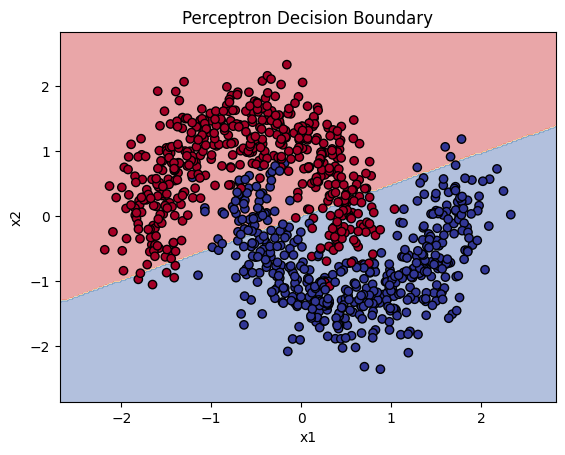

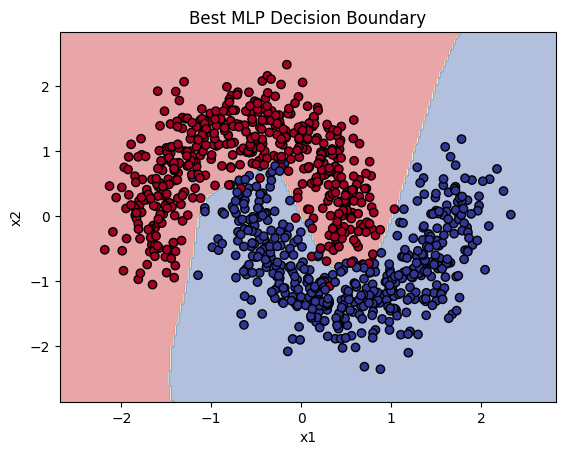

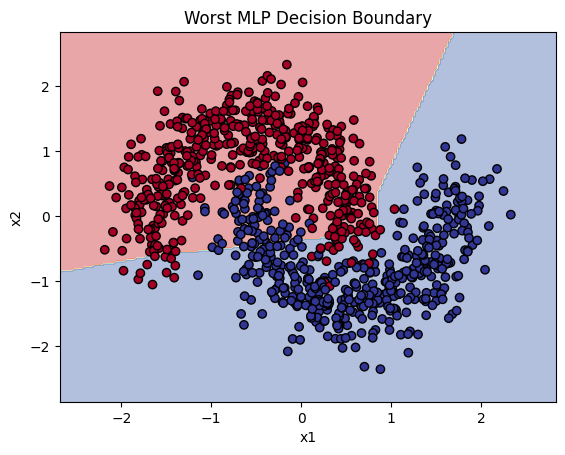

In [23]:
plot_decision_boundary(perceptron_model, X, y,
                       "Perceptron Decision Boundary")

plot_decision_boundary(best_mlp_model, X, y,
                       "Best MLP Decision Boundary")

plot_decision_boundary(worst_mlp_model, X, y,
                       "Worst MLP Decision Boundary")

decision boundary

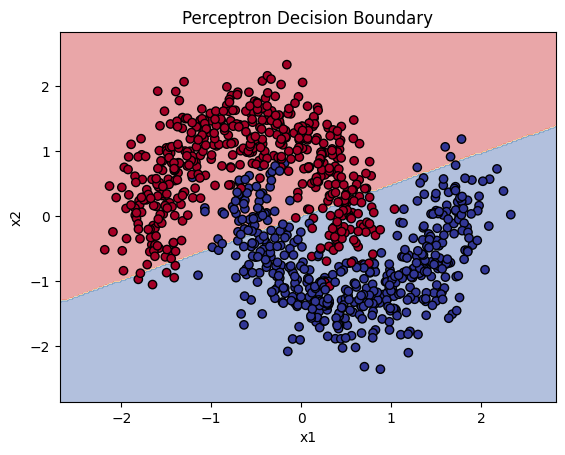

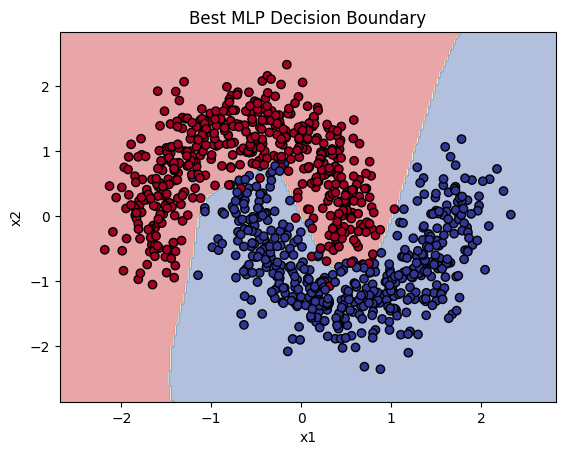

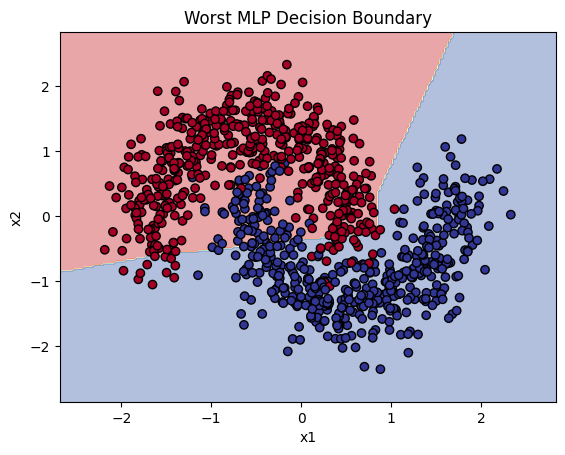

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.FloatTensor(grid)
    with torch.no_grad():
        preds = model(grid_tensor)
        preds = (preds > 0.5).float().numpy()
    
    zz = preds.reshape(xx.shape)
    plt.contourf(xx, yy, zz, alpha=0.4, cmap=plt.cm.RdYlBu)
    
    plt.scatter(X[:,0], X[:,1], c=y.flatten(), cmap=plt.cm.RdYlBu, edgecolors='k')
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

    plot_decision_boundary(perceptron_model, X, y, "Perceptron Decision Boundary")
plot_decision_boundary(best_mlp_model, X, y, "Best MLP Decision Boundary")
plot_decision_boundary(worst_mlp_model, X, y, "Worst MLP Decision Boundary")